In [1]:
import requests
import json
import pandas as pd
import requests
import json



##### But what is an ML Engineer, exactly?
💡 It's a new role that is emerging as data jobs specialize


<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/dajuca/ML_Pictures/refs/heads/main/Figure2-514e275cca0a0450485a49c805aeb321.png" width="40%">
</div>

<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/dajuca/ML_Pictures/refs/heads/main/Figure3-7c5de9f92f3406e23d76e6bff3f89818.png" width="40%">
</div>




💡 It's also emerging as tools become more mature

🤯 The full modern ML stack is way too big to cover in this bootcamp (source)


<div style="text-align: center;">
    <img src="https://raw.githubusercontent.com/dajuca/ML_Pictures/refs/heads/main/ML%20architecture.png" width="80%">
</div>

# Train at Scale # 
## 1) Packaging & Virtual Env 101
### 1.1) What is a Package?


👉 Re-usable code from one project to another (from ... import ...)

A package allows you to:

👉 Share it with others

- Install from [PyPI](https://pypi.org/): pip install <package_name>
- Install from GitHub: pip install git+https://...
👉 Deploy in production (on Linux servers)

👉 Track code (git) and collaborate on it!

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/01_min_package.png" >

- A module is a single python file inside a package
- A package is directory of python modules that contains an additional __init__.py

👉 `__init__.py` allows you to write toto.lib, for instance


```sh
    # CLI (Command Line Interface)
    python -m toto.lib  # Executes as a module
    python toto/lib.py  # Executes as a file



```python 
    from toto.lib import a_function
```

👉 `__init__.py` s content (often empty) is executed at each import line


### Mac users or WSL 



```sh

    mkdir project-toto
    cd project-toto
    mkdir toto
    touch toto/lib.py
    touch toto/__init__.py
    touch setup.py
    code .
```

```python 

    # toto/lib.py
    def who_am_i():
        print("Hello my name is Jean")
    if __name__ == '__main__':
        who_am_i()
```

<!-- 
### Windows users

```sh

mkdir project-toto
cd project-toto
mkdir toto
type nul > toto\lib.py
type nul > toto\__init__.py
type nul > setup.py
code . -->


### 1.2) Virtual environments

🐍 Python Virtual Environments (`venv`) — Editable Install (`pip install -e .`)

This notebook is a **student-ready cheat‑sheet** for projects packaged as a **Python package**  
(using `setup.py`).

install venv : 

`sudo apt install python3-venv`

`python3 -m venv .venv`


#### 1) Create a virtual environment

`python3 -m venv totoenv`

#### 2) Activate the virtual environment

`source totoenv/bin/activate`

#### 3) Verify you are inside the venv

```
which python
which pip
python --version
pip --version


#### 4) Upgrade pip (always do this once)

`python -m pip install --upgrade pip`

#### 5) Editable install of your project

##### What `pip install -e .` does
- Installs your project **as a package**
- Links the package to the local source code
- Any code change is immediately usable (no reinstall)

This is ideal for:
- data pipelines
- ML projects
- APIs
- teaching clean project structure


`pip install -e .`

#### 6) Install additional dependencies (if needed)

Dependencies defined in:

- or `setup.py` → `install_requires`

are installed automatically.

Extra tools can still be added:


`pip install pandas`

#### 7) Check installed packages

`pip freeze`

#### 8) Typical daily workflow (editable install)

```
cd my_project
source .venv/bin/activate
pip install -e .
# edit code
python -m my_package.main
deactivate

#### 9) Common mistakes (avoid)

```bash
pip install -r requirements.txt    # ❌ not needed for packaged projects
sudo pip install -e .              # ❌ never use sudo
pip install .                      # ⚠️ non-editable install
```

✅ Golden rule for development:
```bash
pip install -e .
```


**Install minimal packages for this demo lecture**

```sh 

pip list
pip install --upgrade pip

pip install pandas
pip install ipython   # needed for ipython
pip install ipykernel # needed for notebooks
```

**Reminder on pyenv vs. venv**

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/data-engineering/python_virtual_envs.png" width='100%'> 

### **2) 💻 Installing & Using a Package**

🎯 Goals

`pip install` `toto` in virtual env `totovenv`


### 2.1) Install the Package

**Fill in `setup.py`**

**Install**

Sit next to `setup.py` and run:

```sh
pip install .
```

### 2.2) Run the Package from Anywhere (when totoenv is Activated)


Do not forget to install this before using a notebook or your kernel won't be regonized :

```
source totoenv/bin/activate
python -m pip install -U pip
python -m pip install ipykernel jupyter


**For instance, from a notebook**?



```sh
mkdir notebooks
touch notebooks/notebook.ipynb
```

Open the notebook with VS Code, select `ipykernel=totoenv`, and you should be able to call

```python
from toto.lib import who_am_i
who_am_i()
```

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/totoenv-notebook.png" width='100%'> 

❓ **Why Does it Work?**

🔎 Well, remember that Python's import always looks at your PYTHONPATH

```python

import sys
sys.path
```

Which pyenv always appends with site-packages:

👉 ~/.pyenv/versions/3.8.12/envs/**totoenv**/lib/python3.8/**site-packages**

✅ pip install . creates a **COPY** of your project folder inside <span style="color: blue;">site-packages</span>



<span style="color: blue;">site-packages</span> contains all your pip packages.



🔎 Use it to explore third-party libraries!



<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Pasted_Image_18_05_2022_16_30.png" width='90%'> 

🔥 Hot-Reload on the Package?

```python

def who_am_i():

    print("Hello my name is Jean")
```

👉 Is the modification visible?

❌ No, because pip install . only creates a **COPY** of your project in site-packages

✅ `pip install -e .` (editable) for hot-reloading
- First, pip uninstall toto (move away from setup.py's root to do it properly)
- Then pip install -e .



```python
import toto
toto.__file__ # '~/code/sandbox/project-toto/toto/__init__.py'
```

PS.: for notebooks and `ipython`, don't forget the magic command to avoid closing/reopening `ipython` every time

In [3]:
%load_ext autoreload
%autoreload 2

### 2.3) Dependencies

👉 Let's say we want the `pandas` package to be installed along with `toto`

```python
# toto/lib.py

import pandas as pd

def simple_df():
    df = pd.DataFrame([['Alice', 25], ['Bob', 30]], columns=['Name', 'Age'])
    return df
```

✅ Solution: create `requirements.txt` and update `setup.py`

```sh

# Terminal
touch requirements.txt
echo pandas >> requirements.txt
```

...or specify the version to be used (`pandas==1.1.0`, for example)

```python
# setup.py
from setuptools import setup
from setuptools import find_packages

# list dependencies from file
with open('requirements.txt') as f:
    content = f.readlines()
requirements = [x.strip() for x in content]

setup(name='toto',
      description="package description",
      packages=find_packages(), # NEW: find packages automatically
      install_requires=requirements) # NEW
```

🏁 Then, **pip install -e** . to update `totoenv` with `requirements.txt`


<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Screenshot%202022-05-19%20at%2009.16.57.png" width='80%'> 

**2.4) Adding a Makefile to Create Simple CLI Commands ⚡️**

<div style="text-align: center;">
    <img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/07-ML-OPS/Screenshot%202022-05-19%20at%2009.19.59.png" width='80%'> 

**Makefile Sample**

If not installed it  : 

```
sudo apt update
sudo apt install -y make


`Makefile` How it works



```python
directive_name:
<tab>some command with all its arguments
<tab>@this command will not print out before being executed
<tab>-the command after this one will run no matter what
<tab>-@the markers can be combined
```

**A Simple Makefile**

```python
install:
    @pip install -e .

clean:
    @rm -f */version.txt
    @rm -f .coverage
    @rm -f */.ipynb_checkpoints
    @rm -Rf build
    @rm -Rf */__pycache__
    @rm -Rf */*.pyc
    
all: install clean


💻 Let's run a directive; while sitting next to the `Makefile`:


```sh
tree
make clean
tree
```

Let's run several directives; while sitting next to the `Makefile`:



❗️ The Makefile is highly sensitive:
- Its name is case-sensitive; call it `makefile` and nothing works
- The commands inside of the directives must be indented exclusively using **tabulations**; use one or more spaces instead and nothing works

### 3) Testing your Package 🧪 (A quick overview)


Why should we bother with tests?

- ensures robustness of the project in case of changes
- allows teams to work on the same project without breaking each other's code
- with code, you can "describe" what your code should do better than with words 🔇 (TDD)


👉 Test Driven Development (TDD) consists of writing the tests before the actual code

👉 Most software teams hire full-time testers!

💻 Test Example

# Buisness data management # 
## Business case ## 

**All data**

A luxury consulting cab's engineering team stores all it's product data history in a massive Big Query table `edhec-business-manageme.luxurydata2502.price-monitoring-2022`. 
- These tables contains more than `2 Million` lines.  
- *(Note : In reality, there are way more than 5M rows but we limited that for cost-control in the whole module)*

**Objective**

- The data was extracted from a company study made in `2023`
- The objective is to choose one brand (different from other groups) and make a strategic business analysis about the evolution of this brand, the scope is quite large, you can make pricing analysis, exchange rate analysis, catalogue analysis, market analysis etc.


**Requirements**

- Build a dataset in BigQuery using different sources : 
    - At least one source from API
    - One source from the official brand site (scraped)
    - An extraction of your already chosen brand from the existing Edhec-business-management provided dataset
    - Any other source that you might feel it could be pertinent for your Case Study


**Delivrables**

- One `BigQuery Dataset` with your different tables (please don't forget to grant me access to your project)
- One `github repository` with your structured project as shown in class (init, requirements, makefile, setup.py etc.)
    - The github project should contain the different scripts or methods that you use to scrap, clean your data, call your api, and insert these different tables into your BigQuery project
    - If you don't want to use Github you can also send me your ziped project file
- One `Power BI dashboard` presenting the results of your findings 
    - A structured data relational model with it's correspondant relationships
    - Presentation of your findings
- Bonus : Create a model that you find interesting in this business case and put it in production

## Calling an API
 - Echange rate API : https://app.exchangerate-api.com/

In [14]:
import requests
import pandas as pd

# API URL for exchange rates (USD as base currency)
url = 'https://v6.exchangerate-api.com/v6/4eb043dba172cec94fe70b22/latest/EUR'

# Making the request
response = requests.get(url)
data = response.json()

# Extract the conversion rates dictionary
conversion_rates = data["conversion_rates"]

# Convert to DataFrame
df = pd.DataFrame(list(conversion_rates.items()), columns=["Currency", "Exchange Rate"])


df

,Currency,Exchange Rate
0,EUR,1.0000
1,AED,3.7990
2,AFN,76.9744
3,ALL,98.8331
4,AMD,412.3309
...,...,...
157,XPF,119.3320
158,YER,258.0668
159,ZAR,19.0398
160,ZMW,29.1705


## Creating and Pushing your data to BigQuery
 - If you need to create directories programmatically from within the notebook, you can use Python’s os module:

Also remember to install in your active environment the following libraries : 
- `pip install google-cloud-bigquery`
- `pip install google-oauth2-tool`

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from pathlib import Path
from sklearn import set_config; set_config(display='diagram')
from google.cloud import bigquery
from google.oauth2 import service_account
import os
import warnings
import pandas as pd
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [16]:
from google.cloud import bigquery
from google.oauth2 import service_account

project_id = "edhec-01"  # Replace with your project ID
dataset_id = "luxurydata2502"  # Replace with the name of the dataset you want to create
table_id = "price-monitoring-2022"  

key_path = "/mnt/c/Users/camil/Desktop/BDM 2026/business_data_management/GCPkeys/edhec-01-39bece3963d5.json"

credentials = service_account.Credentials.from_service_account_file(
    key_path
)

client = bigquery.Client(
    credentials=credentials,
    project=project_id
)

## Querying this dataset
 - Not a good practice to put a dataset public but for logistic reasons, the following tables are public during this course ;
    - `edhec-business-manageme.luxurydata2502.price-monitoring-2022`
    - `edhec-business-manageme.luxurydata2502.ficticious-sales`
    - `edhec-business-manageme.luxurydata2502.brand_id`

## Retrieving a sample of your data to BigQuery

- Now that you know how to create a dataset and a structured table within your project we will learn how to query those tables to bring a sample of this dataset into our notebook
- We will use another more structured way to Query than previously so you can have an idea of another way to query Bigquery

In [17]:
import os

base_path = os.path.expanduser("~/business_data_management/data")
os.makedirs(base_path, exist_ok=True)


In [18]:
LOCAL_DATA_PATH = Path('~').joinpath("Desktop", "business_data_management", "data").expanduser()
GCP_PROJECT_EDHEC = project_id
BQ_DATASET = dataset_id
PROJECT_TABLE = "price-monitoring-2022"  
COLUMN_NAMES_RAW = ('uid', 'brand', 'url', 'price', 'currency', 'image_url', 'collection', 'reference_code', 'life_span_date', 'life_span', 
                    'price_before', 'price_difference', 'price_percent_change', 'price_changed')
BRAND = 'Cartier'

**Fill your `GCP_PROJECT` below 👇**
- remember that we previously defined 'project_id' and 'dataset_id' 

In [19]:
print(project_id, dataset_id)

edhec-01 luxurydata2502


In [20]:
GCP_PROJECT = project_id

In [26]:
query = f"""
    SELECT {",".join(COLUMN_NAMES_RAW)}
    FROM `{GCP_PROJECT_EDHEC}.{BQ_DATASET}.{PROJECT_TABLE}`
    WHERE brand = '{BRAND}'
    ORDER BY life_span_date DESC
    LIMIT 10
    """
print(query)



    SELECT uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
    FROM `edhec-01.luxurydata2502.price-monitoring-2022`
    WHERE brand = 'Cartier'
    ORDER BY life_span_date DESC
    LIMIT 10
    


Make the BigQuery call only if file does not already exist locally.  
Else, store locally as CSV to avoid calling BigQuery at each notebook run.

In [27]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = (
    "/mnt/c/Users/camil/Desktop/BDM 2026/business_data_management/GCPkeys/"
    "edhec-01-39bece3963d5.json"
)


In [28]:
data_query_cache_path = Path(LOCAL_DATA_PATH).joinpath(f"query_{BRAND}2.csv")

In [29]:
data_query_cache_path

PosixPath('/home/camil/Desktop/business_data_management/data/query_Cartier2.csv')

In [30]:
if data_query_cache_path.is_file():
    print("load local file...")
    df = pd.read_csv(data_query_cache_path, parse_dates=['life_span_date'])

else:
    print("Querying Big Query server...")
    from google.cloud import bigquery

    client = bigquery.Client(project=GCP_PROJECT)
    query_job = client.query(query)
    result = query_job.result()
    df = result.to_dataframe()

    # df.to_csv(data_query_cache_path, header=True, index=False)


Querying Big Query server...


In [31]:
from pathlib import Path

data_dir = Path.home() / "business_data_management" / "data"
data_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(data_dir / "data.csv", index=False)


In [32]:
df = df.drop_duplicates()
df.shape


(10, 14)

## 1.3) Visualize Data

Text(0.5, 1.0, 'Histogram')

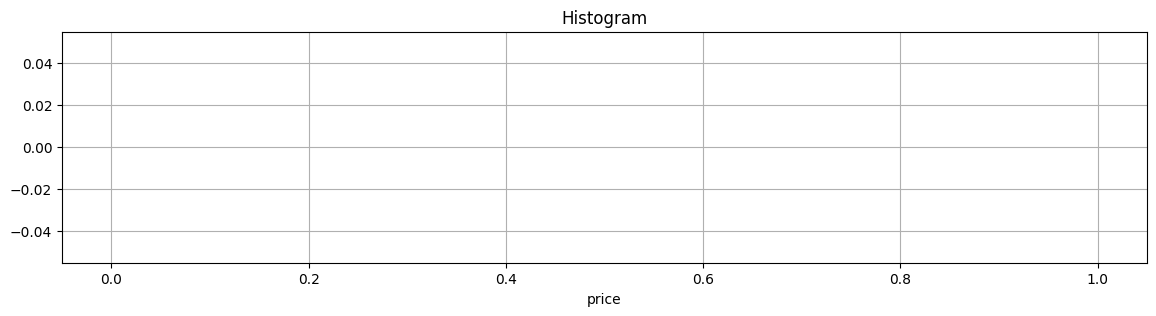

In [33]:
# Plot histogram of fare
df[df['currency'] == 'GBP'].price.hist(bins=100, figsize=(14,3))
plt.xlabel('price')
plt.title('Histogram')

#Values are in different currencies so we can not compare them


In [34]:
df['brand'].value_counts()

brand
Cartier    10
Name: count, dtype: int64

## Small code to check if your dataframe has null values or empty values


In [35]:
import pandas as pd

# Example DataFrame (replace with your actual DataFrame)
# df = df_selected

# Check column data types
print("Column Data Types:")
print(df.dtypes)

# Check for null values
print("\nNull Values in Each Column:")
print(df.isnull().sum())

# Check for empty values (if cell has an empty string "")
print("\nEmpty String Values in Each Column:")
print((df == '').sum())

# Combine both: total nulls and empty values per column
print("\nTotal Null and Empty String Values per Column:")
print((df.isnull() | (df == '')).sum())


Column Data Types:
uid                              Int64
brand                           object
url                             object
price                            Int64
currency                        object
image_url                       object
collection                      object
reference_code                  object
life_span_date          datetime64[us]
life_span                       object
price_before                   float64
price_difference                 Int64
price_percent_change           float64
price_changed                  float64
dtype: object

Null Values in Each Column:
uid                     0
brand                   0
url                     0
price                   0
currency                0
image_url               0
collection              0
reference_code          0
life_span_date          0
life_span               0
price_before            1
price_difference        0
price_percent_change    0
price_changed           0
dtype: int64

Empty String V

## Creating a simple price predict model

In [38]:
# Define project and dataset
project_id = "edhec-01"  # Replace with your project ID
dataset_id = "luxurydata2502"  # Replace with the name of the dataset you want to create
table_id = "price-monitoring-2022"
#key_path = "/Users/juandavidcasascano/Desktop/business_data_management/GCPkeys/edhec-01-39bece3963d5.json"  # Replace with the path to your key file

In [39]:
LOCAL_DATA_PATH = Path('~').joinpath("Desktop", "business_data_management", "data").expanduser()
GCP_PROJECT_EDHEC = project_id
BQ_DATASET = dataset_id
PROJECT_TABLE = "price-monitoring-2022"  
COLUMN_NAMES_RAW = ('uid', 'brand', 'url', 'price', 'currency', 'image_url', 'collection', 'reference_code', 'life_span_date', 'life_span', 
                    'price_before', 'price_difference', 'price_percent_change', 'price_changed')
BRAND = 'Vacheron Constantin'

In [40]:
data_query_cache_path = Path(LOCAL_DATA_PATH).joinpath(f"query_{BRAND}.csv")

In [41]:
query = f"""
    SELECT {",".join(COLUMN_NAMES_RAW)}
    FROM `{GCP_PROJECT_EDHEC}.{BQ_DATASET}.{PROJECT_TABLE}`
    WHERE brand = '{BRAND}'
    ORDER BY life_span_date DESC
    """
print(query)


    SELECT uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
    FROM `edhec-01.luxurydata2502.price-monitoring-2022`
    WHERE brand = 'Vacheron Constantin'
    ORDER BY life_span_date DESC
    


In [43]:
from pathlib import Path
import pandas as pd
from google.cloud import bigquery

data_query_cache_path = (
    Path.home()
    / "business_data_management"
    / "data"
    / "bigquery_cache.csv"
)

data_query_cache_path.parent.mkdir(parents=True, exist_ok=True)

if data_query_cache_path.is_file():
    print("📂 Loading local cache...")
    df = pd.read_csv(
        data_query_cache_path,
        parse_dates=["life_span_date"]
    )

else:
    print("☁️ Querying BigQuery...")
    client = bigquery.Client(project=GCP_PROJECT_EDHEC)

    query_job = client.query(query)
    df = query_job.result().to_dataframe()

    df["life_span_date"] = pd.to_datetime(df["life_span_date"])
    df.to_csv(data_query_cache_path, index=False)

print(f"✅ Rows: {df.shape[0]:,}")


☁️ Querying BigQuery...
✅ Rows: 50,236


In [44]:
df.head(2)

,uid,brand,url,price,currency,image_url,collection,reference_code,life_span_date,life_span,price_before,price_difference,price_percent_change,price_changed
0,3386003,Vacheron Constantin,https://www.vacheron-constantin.com/hk/en/coll...,276000,HKD,https://www.vacheron-constantin.com/dam/rcq/va...,MALTE,VMX81R7710,2022-12-28,Q4 December 2022,276000.0,0,0.0,0.0
1,3386764,Vacheron Constantin,https://www.vacheron-constantin.com/us/en/coll...,19700,USD,https://www.vacheron-constantin.com/dam/rcq/va...,EGERIE,VMX12R2983,2022-12-28,Q4 December 2022,19700.0,0,0.0,0.0


In [45]:
df_cat = df[['brand', 'currency', 'collection', 'life_span']]
df_num = df['price']

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [51]:
# Define the features and target variable
X = df_cat
y = df['price']

# Remove rows where the target variable is NaN or infinite
mask = ~np.isnan(y) & ~np.isinf(y)
X = X[mask]
y = y[mask]

# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded = encoder.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=0)




In [52]:
# Define the model
model = KNeighborsRegressor(n_neighbors=5)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 53879271131601.29
R-squared: 0.7025793485723402
